In [5]:
using Random
using Distributions
using Plots
using StatsPlots

function psi_waiting_time(k, nr)
    """
    Generates a random time from the waiting time distribution psi(t) = k e^-kt.

    Repeat nr times.

    Args:
        k: The rate parameter of the distribution.
        nr: The number of times to repeat the process.

    Returns:
        A random time array generated from the distribution.
    """
    return -log.(rand(nr)) / k
end

function random_walker_parallel(kL, kR, m, t, nr)
    """
    Args:
    kL, kR: rate coefficient
    m: initial position
    t: measuring time (final)
    nr: number of repeatation.

    Returns:
        positions of random walkers which starts at lattice site m.   
    """
    time = zeros(nr)
    position = m * ones(nr)

    while true
        tL = psi_waiting_time(kL, nr)
        tR = psi_waiting_time(kR, nr)

        B_left = tL .< tR
        B_right = tL .> tR

        time .+= tL .* B_left + tR .* B_right
        B_time = time .< t

        position .-= B_left .* B_time
        position .+= B_right .* B_time

        if sum(B_time) == 0
            break
        end
    end
    
    return position
end


random_walker_parallel (generic function with 1 method)

In [6]:
nr = 10000000
time = 10000

results_many = random_walker_parallel(1,1,0,time, nr);

In [7]:
function normal_distribution(sigma, x, m)
    return exp.(-0.5 .* ((x .- m) ./ sigma).^2) ./ sqrt(2 * π * sigma^2)
end

normal_distribution (generic function with 1 method)

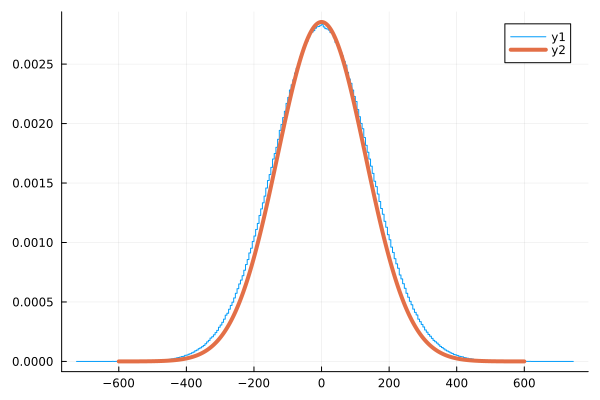

In [18]:
x_axis = LinRange(-600,600,1201)

histogram(results_many, bins = 400, normalize=true)
plot!(x_axis, 0.93*normal_distribution(130,x_axis,0), lw = 4)
